# Module 2 — RoBERTa Fine-Tuning for Claim Verification
## Misinformation Verification Pipeline
### Input: features.json (from Module 1)
### Output: roberta_scores.json — per-claim predictions and confidence scores

In [1]:
!pip install transformers datasets torch scikit-learn -q

import json
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    RobertaTokenizer,
    RobertaForSequenceClassification,
    get_linear_schedule_with_warmup
)
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

# Check GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: Tesla T4


In [2]:
# All hyperparameters in one place — easy to change
CONFIG = {
    "model_name":    "roberta-base",
    "max_length":    128,
    "batch_size":    16,
    "epochs":        3,
    "learning_rate": 2e-5,
    "warmup_steps":  100,
    "num_labels":    6,        # 6-way: pants-fire to true
    "seed":          42,
}

LABEL_TO_INT = {
    "pants-fire":  0,
    "false":       1,
    "barely-true": 2,
    "half-true":   3,
    "mostly-true": 4,
    "true":        5
}

INT_TO_LABEL = {v: k for k, v in LABEL_TO_INT.items()}

torch.manual_seed(CONFIG["seed"])
np.random.seed(CONFIG["seed"])
print("Config ready.")
print(CONFIG)

Config ready.
{'model_name': 'roberta-base', 'max_length': 128, 'batch_size': 16, 'epochs': 3, 'learning_rate': 2e-05, 'warmup_steps': 100, 'num_labels': 6, 'seed': 42}


In [3]:
with open("/kaggle/input/datasets/shyneyhxrsh/features/features.json") as f:
    records = json.load(f)

print(f"Loaded {len(records)} records")

# Split into train / val / test
train_records = [r for r in records if r["split"] == "train"]
val_records   = [r for r in records if r["split"] == "val"]
test_records  = [r for r in records if r["split"] == "test"]

print(f"Train: {len(train_records)} | Val: {len(val_records)} | Test: {len(test_records)}")
print(f"\nSample: {train_records[0]['raw_claim'][:80]}...")
print(f"Label:  {train_records[0]['label']}")

Loaded 12791 records
Train: 10240 | Val: 1284 | Test: 1267

Sample: Says the Annies List political group supports third-trimester abortions on deman...
Label:  false


## 1. Dataset Class
We wrap the records in a PyTorch Dataset so DataLoader can batch them.
Each claim text is tokenized by RoBERTa's tokenizer — it handles
subword splitting, padding, and attention masks automatically.

In [4]:
class LIARDataset(Dataset):
    def __init__(self, records, tokenizer, max_length):
        self.records    = records
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        record = self.records[idx]
        text   = record["raw_claim"]
        label  = LABEL_TO_INT.get(record["label"], 3)  # default half-true

        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "label":          torch.tensor(label, dtype=torch.long),
            "claim_id":       record["claim_id"],
        }


# Load tokenizer
print("Loading RoBERTa tokenizer...")
tokenizer = RobertaTokenizer.from_pretrained(CONFIG["model_name"])

# Create datasets
train_dataset = LIARDataset(train_records, tokenizer, CONFIG["max_length"])
val_dataset   = LIARDataset(val_records,   tokenizer, CONFIG["max_length"])
test_dataset  = LIARDataset(test_records,  tokenizer, CONFIG["max_length"])

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["batch_size"], shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG["batch_size"], shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

Loading RoBERTa tokenizer...


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Train batches: 640
Val batches:   81
Test batches:  80


## 2. Load Pre-trained RoBERTa
We load roberta-base with a classification head on top.
The classification head is randomly initialised — fine-tuning
adjusts both the head and the pre-trained weights together.

In [5]:
print("Loading RoBERTa model...")
model = RobertaForSequenceClassification.from_pretrained(
    CONFIG["model_name"],
    num_labels=CONFIG["num_labels"]
)
model = model.to(device)

# Count parameters
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

Loading RoBERTa model...


config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     124,650,246
Trainable parameters: 124,650,246


## 3. Training Setup
- **Optimiser**: AdamW — standard for transformer fine-tuning
- **Scheduler**: linear warmup then decay — prevents large early updates
- **Loss**: cross-entropy over 6 classes

In [6]:
optimizer = AdamW(
    model.parameters(),
    lr=CONFIG["learning_rate"],
    weight_decay=0.01
)

total_steps = len(train_loader) * CONFIG["epochs"]

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=CONFIG["warmup_steps"],
    num_training_steps=total_steps
)

print(f"Total training steps: {total_steps}")
print(f"Warmup steps: {CONFIG['warmup_steps']}")

Total training steps: 1920
Warmup steps: 100


## 4. Fine-Tuning
Train for 3 epochs. We track loss and accuracy on both
train and validation sets each epoch.
On a T4 GPU this takes approximately 20 minutes.

In [7]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in tqdm(loader, desc="Training"):
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids,
                        attention_mask=attention_mask,
                        labels=labels)

        loss = outputs.loss
        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    return total_loss / len(loader), correct / total


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["label"].to(device)

            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask,
                            labels=labels)

            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=-1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), correct / total, all_preds, all_labels


# Training loop
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc = 0

print("Starting training...\n")
for epoch in range(CONFIG["epochs"]):
    print(f"Epoch {epoch+1}/{CONFIG['epochs']}")

    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_acc, val_preds, val_labels = eval_epoch(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}\n")

    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "best_roberta.pt")
        print(f"  ✓ Best model saved (val_acc={val_acc:.4f})\n")

print(f"Training complete. Best val accuracy: {best_val_acc:.4f}")

Starting training...

Epoch 1/3


Evaluating: 100%|██████████| 81/81 [00:09<00:00,  8.55it/s]


  Train Loss: 1.7404 | Train Acc: 0.2191
  Val Loss:   1.6977 | Val Acc:   0.2593

  ✓ Best model saved (val_acc=0.2593)

Epoch 2/3


Evaluating: 100%|██████████| 81/81 [00:09<00:00,  8.50it/s]


  Train Loss: 1.6547 | Train Acc: 0.2870
  Val Loss:   1.6515 | Val Acc:   0.2913

  ✓ Best model saved (val_acc=0.2913)

Epoch 3/3


Evaluating: 100%|██████████| 81/81 [00:09<00:00,  8.53it/s]

  Train Loss: 1.5328 | Train Acc: 0.3612
  Val Loss:   1.6948 | Val Acc:   0.2788

Training complete. Best val accuracy: 0.2913


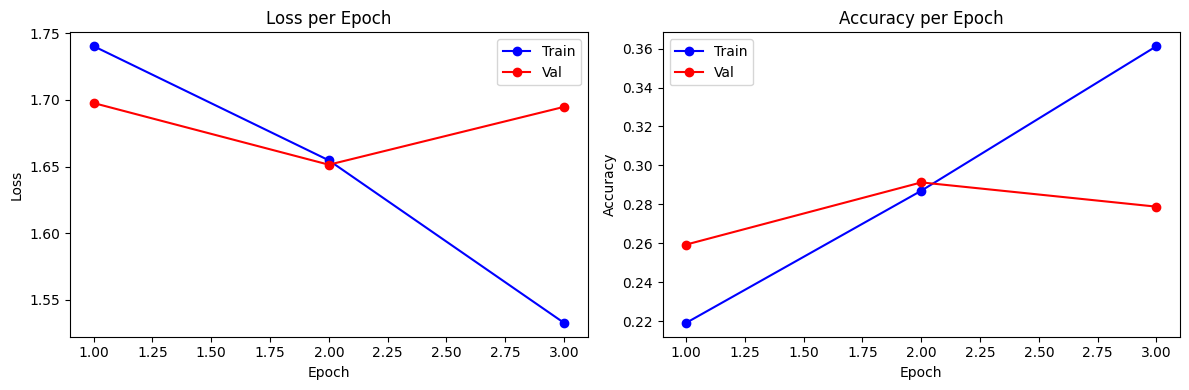

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

epochs_range = range(1, CONFIG["epochs"] + 1)

ax1.plot(epochs_range, history["train_loss"], "b-o", label="Train")
ax1.plot(epochs_range, history["val_loss"],   "r-o", label="Val")
ax1.set_title("Loss per Epoch")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()

ax2.plot(epochs_range, history["train_acc"], "b-o", label="Train")
ax2.plot(epochs_range, history["val_acc"],   "r-o", label="Val")
ax2.set_title("Accuracy per Epoch")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()

plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
# Load best model
model.load_state_dict(torch.load("best_roberta.pt"))
print("Loaded best model.")

test_loss, test_acc, test_preds, test_labels = eval_epoch(model, test_loader, device)

print(f"\nTest Accuracy: {test_acc:.4f}")
print(f"Test Loss:     {test_loss:.4f}")

label_names = [INT_TO_LABEL[i] for i in range(6)]
print("\nClassification Report:")
print(classification_report(test_labels, test_preds, target_names=label_names))

Loaded best model.


Evaluating: 100%|██████████| 80/80 [00:09<00:00,  8.58it/s]


Test Accuracy: 0.2928
Test Loss:     1.6388

Classification Report:
              precision    recall  f1-score   support

  pants-fire       0.41      0.17      0.24        92
       false       0.31      0.38      0.34       249
 barely-true       0.26      0.27      0.27       212
   half-true       0.31      0.21      0.25       265
 mostly-true       0.28      0.39      0.32       241
        true       0.30      0.25      0.27       208

    accuracy                           0.29      1267
   macro avg       0.31      0.28      0.28      1267
weighted avg       0.30      0.29      0.29      1267



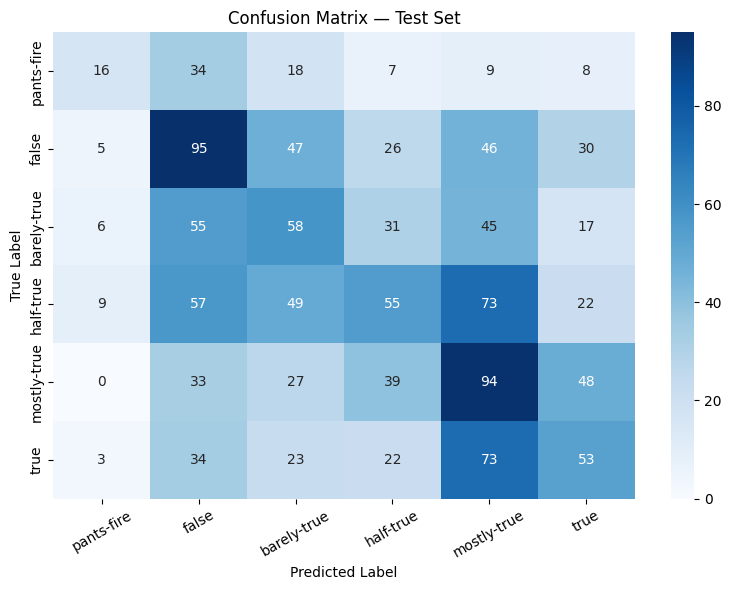

In [10]:
cm = confusion_matrix(test_labels, test_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names,
            yticklabels=label_names)
plt.title("Confusion Matrix — Test Set")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Generate Scores for All 12,791 Records
Run the full dataset through the model to get per-claim
probability distributions. These feed into Module 4 (Bayesian fusion).

In [11]:
def get_all_scores(model, records, tokenizer, device, batch_size=32):
    model.eval()
    all_results = []

    for i in tqdm(range(0, len(records), batch_size), desc="Scoring"):
        batch_records = records[i:i+batch_size]
        texts = [r["raw_claim"] for r in batch_records]

        encodings = tokenizer(
            texts,
            max_length=CONFIG["max_length"],
            padding=True,
            truncation=True,
            return_tensors="pt"
        )

        input_ids      = encodings["input_ids"].to(device)
        attention_mask = encodings["attention_mask"].to(device)

        with torch.no_grad():
            outputs = model(input_ids=input_ids,
                            attention_mask=attention_mask)
            probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

        for j, r in enumerate(batch_records):
            prob_dist = {INT_TO_LABEL[k]: round(float(probs[j][k]), 4)
                         for k in range(6)}

            pred_int  = int(np.argmax(probs[j]))
            pred_label = INT_TO_LABEL[pred_int]
            confidence = round(float(probs[j][pred_int]), 4)

            # Binary score — probability of being true (labels 4+5)
            binary_true_prob = round(
                float(probs[j][4] + probs[j][5]), 4
            )

            all_results.append({
                "claim_id":         r["claim_id"],
                "raw_claim":        r["raw_claim"],
                "label":            r["label"],
                "label_binary":     r.get("label_binary"),
                "split":            r["split"],
                "speaker":          r["speaker"],
                "speaker_lie_rate": r["speaker_lie_rate"],
                "roberta_pred":     pred_label,
                "roberta_confidence": confidence,
                "roberta_true_prob":  binary_true_prob,
                "roberta_probs":    prob_dist,
            })

    return all_results


print("Generating scores for all records...")
roberta_scores = get_all_scores(model, records, tokenizer, device)
print(f"Done. {len(roberta_scores)} records scored.")


Generating scores for all records...


Scoring: 100%|██████████| 400/400 [00:38<00:00, 10.49it/s]

Done. 12791 records scored.


In [12]:
with open("roberta_scores.json", "w", encoding="utf-8") as f:
    json.dump(roberta_scores, f, indent=2, ensure_ascii=False)

print(f"Saved {len(roberta_scores)} records to roberta_scores.json")
print("\nSample output record:")
print(json.dumps(roberta_scores[2], indent=2))

Saved 12791 records to roberta_scores.json

Sample output record:
{
  "claim_id": "324.json",
  "raw_claim": "Hillary Clinton agrees with John McCain \"by voting to give George Bush the benefit of the doubt on Iran.\"",
  "label": "mostly-true",
  "label_binary": 1.0,
  "split": "train",
  "speaker": "barack-obama",
  "speaker_lie_rate": 0.3171,
  "roberta_pred": "mostly-true",
  "roberta_confidence": 0.2459,
  "roberta_true_prob": 0.4736,
  "roberta_probs": {
    "pants-fire": 0.0307,
    "false": 0.1612,
    "barely-true": 0.1615,
    "half-true": 0.173,
    "mostly-true": 0.2459,
    "true": 0.2276
  }
}


In [13]:
df_scores = pd.DataFrame(roberta_scores)
df_test_scores = df_scores[df_scores["split"] == "test"]

# Binary accuracy on test
df_test_binary = df_test_scores[df_test_scores["label_binary"].notna()].copy()
df_test_binary["pred_binary"] = df_test_binary["roberta_true_prob"].apply(
    lambda x: 1 if x >= 0.5 else 0
)
binary_acc = (df_test_binary["pred_binary"] == df_test_binary["label_binary"]).mean()

print("=" * 50)
print("Module 2 — RoBERTa Fine-Tuning Complete")
print("=" * 50)
print(f"Test accuracy (6-way):  {test_acc:.4f}")
print(f"Test accuracy (binary): {binary_acc:.4f}")
print(f"Best val accuracy:      {best_val_acc:.4f}")
print(f"Total records scored:   {len(roberta_scores)}")
print(f"\nOutput: roberta_scores.json")
print(f"Next:   Module 3 — Knowledge Graph")

Module 2 — RoBERTa Fine-Tuning Complete
Test accuracy (6-way):  0.2928
Test accuracy (binary): 0.6737
Best val accuracy:      0.2913
Total records scored:   12791

Output: roberta_scores.json
Next:   Module 3 — Knowledge Graph
